# Session 8: Linear Regression, Visualization

Last session we covered the ideas: a line `ŷ = wx + b`, residuals as vertical gaps, MSE as the average squared residual, and the big claim that **training a model = finding the parameters that minimise the loss**.

This session, you'll explore all those concepts in an interactive session. No new theory. We'll:

1. Drag `w` and `b` and watch the line — and the loss — change in real time.
2. See the loss curve and the loss landscape that you've been moving through.
3. Compare MSE vs. MAE when there's an outlier in the data.
4. Add your own data point and watch the loss respond.
5. Do the same exploration on real penguin data, then compare your best guess to what `sklearn` finds.

## Quick recall before we start

Before we go further, quick revision on the concepts:

1. **Residual** = the vertical gap between an actual data point `yᵢ` and the line's prediction `ŷᵢ`. Formula: `rᵢ = yᵢ − ŷᵢ`.
2. **MSE** averages the *squared* residuals. **MAE** averages the *absolute* residuals. MSE punishes big errors more.
3. **Training** = finding the parameters `(w, b)` that make the loss as small as possible.

</details>

## Step 0 — Setup

Run this cell once. It imports the libraries we'll use and generates a small toy dataset.

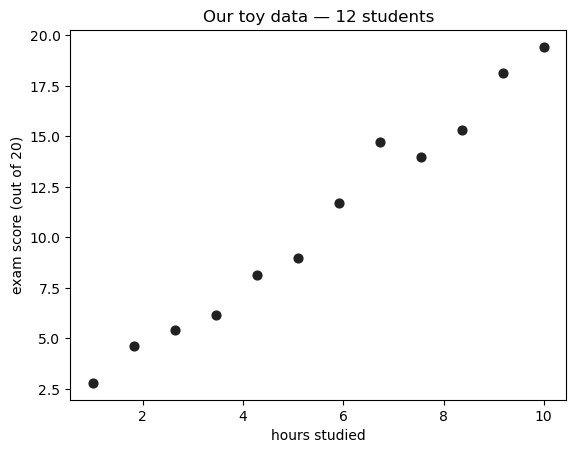

We have 12 students.
The 'true' (hidden) relationship is:  score = 1.8 × hours + 1.0
In words: each extra hour adds ~1.8 points, with ~1.0 baseline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons, fixed, VBox, HBox, Output
from IPython.display import display

%matplotlib inline

# A small toy dataset: hours studied → exam score (out of 20)
# Each point is one student.
rng = np.random.default_rng(7)
hours = np.linspace(1, 10, 12)
true_w, true_b = 1.8, 1.0
score = true_w * hours + true_b + rng.normal(0, 1.2, size=hours.size)

# We'll keep using x and y as the variable names in the code below,
# since those are the standard ML names. Just remember:
#   x = hours studied,  y = exam score (out of 20)
x, y = hours, score

# Style helpers
RED = '#B85042'
INK = '#212121'
MUTED = '#6C757D'

plt.scatter(x, y, color=INK, s=40)
plt.xlabel('hours studied'); plt.ylabel('exam score (out of 20)')
plt.title('Our toy data — 12 students')
plt.show()

print(f"We have {len(x)} students.")
print(f"The 'true' (hidden) relationship is:  score = {true_w} × hours + {true_b}")
print(f"In words: each extra hour adds ~{true_w} points, with ~{true_b} baseline.")


## 1 — Drag the line. Watch the loss.

Move the sliders for `w` (slope) and `b` (intercept). The line updates instantly. So do the loss numbers below.

**Goal:** Try to get both MSE and MAE as small as you can. What values of `w` and `b` do you end up with?

In [ ]:
def plot_line_with_loss(w, b):
    y_pred = w * x + b
    residuals = y - y_pred
    mse = np.mean(residuals ** 2)
    mae = np.mean(np.abs(residuals))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    # residual lines
    for xi, yi, ypi in zip(x, y, y_pred):
        ax.vlines(xi, min(yi, ypi), max(yi, ypi), colors=MUTED, linestyles='--', lw=0.9, alpha=0.7)
    ax.scatter(x, y, color=INK, s=40, zorder=3)
    xs = np.array([x.min() - 0.5, x.max() + 0.5])
    ax.plot(xs, w * xs + b, color=RED, lw=2.2, zorder=2)
    ax.set_xlabel('hours studied'); ax.set_ylabel('exam score')
    ax.set_title(f'score = {w:.2f} × hours + {b:.2f}      |      MSE = {mse:.3f}      MAE = {mae:.3f}',
                 fontsize=12)
    ax.set_xlim(0, 11); ax.set_ylim(-2, 22)
    plt.show()

interact(plot_line_with_loss,
         w=FloatSlider(value=0.5, min=-1, max=4, step=0.05, description='slope w'),
         b=FloatSlider(value=0.0, min=-5, max=10, step=0.1, description='intercept b'));

interactive(children=(FloatSlider(value=0.5, description='slope w', max=4.0, min=-1.0, step=0.05), FloatSlider…

> **Try this:**
> - Set `w = 1.8` and `b = 1.0`. (That's the *true* relationship: about 1.8 extra points per hour studied, with ~1 point baseline.) Note the loss is small, but not zero — students vary.
> - Now make `w` clearly too big (say, `w = 3.5`) or too small (`w = 0.2`). Watch the residual lines stretch out and the MSE balloon.
> - Notice MSE changes *faster* than MAE when the line gets very wrong. That's the squaring at work.
>
> Sanity-check: a slope of `1.8` means *every extra hour of study adds 1.8 points*. Does the data look like it agrees?

## 2 — The loss curve

We just claimed the loss is a function of the parameters. Let's plot that.

Below, we **fix `b`** at a reasonable value and **sweep `w`** across a range. The red curve is `MSE(w)`. The dot is where your current `w` slider sits on that curve.

Move `w` — the dot slides along the curve.

In [ ]:
def plot_loss_curve(w, b):
    ws = np.linspace(-2, 5, 200)
    losses = np.array([np.mean((y - (wi * x + b))**2) for wi in ws])
    current_loss = np.mean((y - (w * x + b))**2)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # left: data + current line
    ax = axes[0]
    ax.scatter(x, y, color=INK, s=35, zorder=3)
    xs = np.array([x.min() - 0.5, x.max() + 0.5])
    ax.plot(xs, w * xs + b, color=RED, lw=2.2)
    ax.set_xlim(0, 11); ax.set_ylim(-2, 22)
    ax.set_title(f'data + your line (w={w:.2f}, b={b:.2f})')
    ax.set_xlabel('hours studied'); ax.set_ylabel('exam score')

    # right: loss curve
    ax = axes[1]
    ax.plot(ws, losses, color=RED, lw=2)
    ax.scatter([w], [current_loss], color=INK, s=80, zorder=5, edgecolor='white', linewidth=2)
    ax.set_xlabel('slope w'); ax.set_ylabel('MSE(w)')
    ax.set_title(f'loss curve (b fixed at {b})      |      current MSE = {current_loss:.3f}')
    ax.axhline(0, color=MUTED, lw=0.5)
    plt.tight_layout()
    plt.show()

interact(plot_loss_curve,
         w=FloatSlider(value=0.5, min=-2, max=5, step=0.05, description='slope w'),
         b=FloatSlider(value=1.0, min=-3, max=5, step=0.1, description='intercept b (fixed-ish)'));

interactive(children=(FloatSlider(value=0.5, description='slope w', max=5.0, min=-2.0, step=0.05), FloatSlider…

> **Try this:**
> - Drag `w` from far left to far right. Watch the dot trace out the bowl.
> - The bottom of the bowl is the best "points-per-hour" slope (for the current baseline `b`). Roughly what value of `w` is it at? Does it match your intuition from the data?
> - Now change `b`. The whole curve shifts. So the "best `w`" depends on `b` — and vice versa. That's why the real problem is 2D.

## 3 — The 2D loss landscape

If we let *both* `w` and `b` vary, the loss isn't a curve anymore — it's a surface over the `(w, b)` plane. The picture below shows that surface as a **contour map**, like a topographic map: closed loops are valleys and peaks.

The black dot is **your current `(w, b)`**. The white star is **the true minimum**.

Move the sliders. Try to walk the dot onto the star.

In [ ]:
# Precompute the loss surface once
ws_grid = np.linspace(-1, 4, 80)
bs_grid = np.linspace(-5, 8, 80)
W, B = np.meshgrid(ws_grid, bs_grid)
# vectorised MSE over the grid
L = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L[i, j] = np.mean((y - (W[i, j] * x + B[i, j]))**2)
# argmin on the grid (close to true minimum)
flat_argmin = np.argmin(L)
best_w_grid = W.flatten()[flat_argmin]
best_b_grid = B.flatten()[flat_argmin]

def plot_landscape(w, b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    # left: scatter + line
    ax = axes[0]
    ax.scatter(x, y, color=INK, s=35, zorder=3)
    xs = np.array([x.min() - 0.5, x.max() + 0.5])
    ax.plot(xs, w * xs + b, color=RED, lw=2.2)
    ax.set_xlim(0, 11); ax.set_ylim(-2, 22)
    current_loss = np.mean((y - (w * x + b))**2)
    ax.set_title(f'your line     |     MSE = {current_loss:.3f}')
    ax.set_xlabel('hours studied'); ax.set_ylabel('exam score')

    # right: contour plot
    ax = axes[1]
    levels = np.geomspace(L.min() + 0.1, L.max(), 20)
    cs = ax.contourf(W, B, L, levels=levels, cmap='Reds', alpha=0.85)
    ax.contour(W, B, L, levels=levels, colors='white', linewidths=0.4, alpha=0.5)
    ax.scatter([best_w_grid], [best_b_grid], marker='*', s=300,
               color='white', edgecolor=INK, linewidth=1.5, zorder=5, label='best (w, b)')
    ax.scatter([w], [b], color=INK, s=80, zorder=6, edgecolor='white', linewidth=2, label='your (w, b)')
    ax.set_xlabel('slope w'); ax.set_ylabel('intercept b')
    ax.set_title('loss landscape — get the dot to the star')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(plot_landscape,
         w=FloatSlider(value=0.5, min=-1, max=4, step=0.05, description='slope w'),
         b=FloatSlider(value=0.0, min=-5, max=8, step=0.1, description='intercept b'));


interactive(children=(FloatSlider(value=0.5, description='slope w', max=4.0, min=-1.0, step=0.05), FloatSlider…

> **Try this:**
> - The loss landscape is a **bowl** — one minimum, no other low spots. That's special to linear regression with MSE. Neural networks have horrible mountain-range landscapes.
> - "Training" is the act of walking your dot (your current guess for points-per-hour and baseline) to the star (the best guess).
> - Try grid-searching by eye: scan `w` slowly, then for each `w` find the best `b`. Notice how much work that already is — and we only have 2 parameters. Imagine doing this for a million.

## 4 — MSE vs MAE: what happens with an outlier?

Here are the standard formulas.

### Mean Squared Error (MSE)

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Where:
- $n$ = number of samples
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value

**Interpretation:** Squares each error before averaging, so larger errors are penalized much more heavily.

---

### Mean Absolute Error (MAE)

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|
$$

Where:
- $n$ = number of samples
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value

**Interpretation:** Computes the average absolute difference between the predicted and actual values. All errors are weighted equally.

---


Since MSE squares the individual residuals, it "punishes big errors more." Let's see that in action. Due to this it is more prone to outliers.

The slider below moves **one of the data points up or down** — making it an outlier when you push it far from the others. Watch how the best-fit line (computed automatically for each loss) reacts.

**MSE** chases the outlier hard. **MAE** mostly ignores it.

In [7]:
def fit_mse(xv, yv):
    # closed-form least squares
    n = len(xv)
    w = (n * np.sum(xv*yv) - np.sum(xv)*np.sum(yv)) / (n*np.sum(xv**2) - np.sum(xv)**2)
    b = (np.sum(yv) - w * np.sum(xv)) / n
    return w, b

def fit_mae(xv, yv, n_iter=200):
    # simple iterative reweighting — good enough for demo
    w, b = fit_mse(xv, yv)
    for _ in range(n_iter):
        residuals = yv - (w * xv + b)
        weights = 1.0 / (np.abs(residuals) + 1e-6)
        sw = np.sum(weights)
        sxw = np.sum(weights * xv)
        syw = np.sum(weights * yv)
        sxxw = np.sum(weights * xv**2)
        sxyw = np.sum(weights * xv * yv)
        denom = sw * sxxw - sxw**2
        if abs(denom) < 1e-12: break
        w = (sw * sxyw - sxw * syw) / denom
        b = (syw - w * sxw) / sw
    return w, b

def plot_outlier_effect(outlier_shift, loss_type):
    # Move the last data point up/down by outlier_shift
    y_mod = y.copy()
    y_mod[-1] = y[-1] + outlier_shift

    w_mse, b_mse = fit_mse(x, y_mod)
    w_mae, b_mae = fit_mae(x, y_mod)

    fig, ax = plt.subplots(figsize=(9, 5))
    # plot all but outlier
    ax.scatter(x[:-1], y_mod[:-1], color=INK, s=40, zorder=3)
    # plot outlier specially
    ax.scatter([x[-1]], [y_mod[-1]], color=RED, s=120, zorder=4,
               edgecolor='white', linewidth=2, label='outlier (you control)')

    xs = np.array([x.min() - 0.5, x.max() + 0.5])
    if loss_type in ['MSE', 'Both']:
        ax.plot(xs, w_mse * xs + b_mse, color=RED, lw=2.5,
                label=f'best-fit by MSE (w={w_mse:.2f})')
    if loss_type in ['MAE', 'Both']:
        ax.plot(xs, w_mae * xs + b_mae, color=INK, lw=2.5, linestyle='--',
                label=f'best-fit by MAE (w={w_mae:.2f})')

    ax.set_xlim(0, 11); ax.set_ylim(-10, 35)
    ax.set_xlabel('hours studied'); ax.set_ylabel('exam score')
    ax.set_title(f'outlier shift = {outlier_shift:+.1f}     |     loss = {loss_type}')
    ax.legend(loc='upper left', fontsize=10)
    plt.show()

interact(plot_outlier_effect,
         outlier_shift=FloatSlider(value=0.0, min=-15, max=15, step=0.5, description='outlier ↕'),
         loss_type=ToggleButtons(options=['MSE', 'MAE', 'Both'], value='Both', description='loss:'));


interactive(children=(FloatSlider(value=0.0, description='outlier ↕', max=15.0, min=-15.0, step=0.5), ToggleBu…

> **Try this:**
> - Push the outlier up by +10. Imagine: one student studied 10 hours but happened to score 10 points higher than the trend — maybe they got lucky, maybe they were a strong student to begin with. Watch the MSE line (red, solid) tilt to follow them. The MAE line (black, dashed) barely moves.
> - Now push it down by -10 (a strong student who had a bad day). Same effect, opposite direction.
> - This is the **robustness** tradeoff. MAE is what you want when your data has weird outliers you want to *ignore*. MSE is what you want when every error counts.
> - For most ML problems (and the rest of this course), MSE is the default. But it's not always the right choice — and now you've seen *why*.

## 5 — Add your own data point

Use the sliders to add a new point at `(px, py)`. Watch how both losses (MSE and MAE) change for your current best-guess line.

This builds the intuition: **the loss is a function not just of the parameters, but of the data.** Change the data → change the loss landscape.

In [8]:
def plot_add_point(px, py, w, b):
    x_aug = np.append(x, px)
    y_aug = np.append(y, py)
    y_pred = w * x_aug + b
    residuals = y_aug - y_pred
    mse = np.mean(residuals ** 2)
    mae = np.mean(np.abs(residuals))

    # loss without the new point, for comparison
    y_pred_orig = w * x + b
    mse_orig = np.mean((y - y_pred_orig) ** 2)
    mae_orig = np.mean(np.abs(y - y_pred_orig))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(x, y, color=INK, s=40, zorder=3, label='original data')
    ax.scatter([px], [py], color=RED, s=150, zorder=4, marker='X',
               edgecolor='white', linewidth=2, label='your new point')
    xs = np.array([x.min() - 0.5, max(x.max(), px) + 0.5])
    ax.plot(xs, w * xs + b, color=RED, lw=2.2, label=f'ŷ = {w:.2f}x + {b:.2f}')
    ax.set_xlim(-1, 12); ax.set_ylim(-5, 30)
    ax.set_xlabel('hours studied'); ax.set_ylabel('exam score')
    ax.set_title(f'MSE: {mse_orig:.3f} → {mse:.3f}     |     MAE: {mae_orig:.3f} → {mae:.3f}')
    ax.legend(loc='upper left', fontsize=10)
    plt.show()

interact(plot_add_point,
         px=FloatSlider(value=5.0, min=-1, max=12, step=0.2, description='new hours'),
         py=FloatSlider(value=10.0, min=-5, max=30, step=0.5, description='new score'),
         w=FloatSlider(value=1.8, min=-1, max=4, step=0.05, description='slope w'),
         b=FloatSlider(value=1.0, min=-5, max=8, step=0.1, description='intercept b'));


interactive(children=(FloatSlider(value=5.0, description='new hours', max=12.0, min=-1.0, step=0.2), FloatSlid…

> **Try this:**
> - Add a new student who fits the trend exactly (e.g. 6 hours, ~12 points). Both losses *decrease* — the new point makes the line look better.
> - Add a wildly off-trend student (e.g. 6 hours, 25 points). Both losses jump — MSE jumps more.
> - The takeaway: **the loss surface itself depends on the data**. New data → new landscape → new "best" parameters.

## 6 — Now with real data: penguins 🐧

Toy data is clean. Real data is messier — but the ideas are the same. Let's do the slider exploration with penguin **flipper length** (mm) → **body mass** (g).

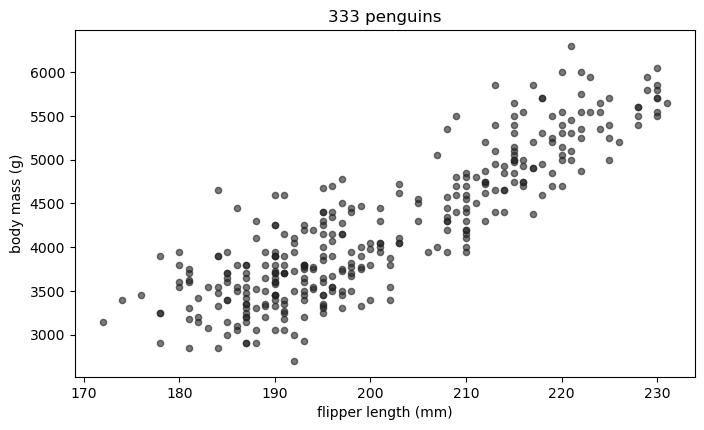

In [9]:
import pandas as pd

URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
try:
    penguins = pd.read_csv(URL).dropna()
except Exception:
    # fallback: synthesize penguin-like data
    rng2 = np.random.default_rng(42)
    flipper = np.linspace(170, 230, 100)
    mass = 50 * flipper - 5800 + rng2.normal(0, 350, size=flipper.size)
    penguins = pd.DataFrame({'flipper_length_mm': flipper, 'body_mass_g': mass})

px_data = penguins['flipper_length_mm'].values
py_data = penguins['body_mass_g'].values

plt.figure(figsize=(8, 4.5))
plt.scatter(px_data, py_data, color=INK, s=20, alpha=0.6)
plt.xlabel('flipper length (mm)'); plt.ylabel('body mass (g)')
plt.title(f'{len(px_data)} penguins')
plt.show()

Same widget, real data. The scales are bigger (slope is around 50, intercept is around -5800) — note the slider ranges below.

In [10]:
def plot_penguin_line(w, b):
    y_pred = w * px_data + b
    mse = np.mean((py_data - y_pred) ** 2)
    mae = np.mean(np.abs(py_data - y_pred))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(px_data, py_data, color=INK, s=18, alpha=0.6, zorder=3)
    xs = np.array([px_data.min() - 2, px_data.max() + 2])
    ax.plot(xs, w * xs + b, color=RED, lw=2.5, zorder=4)
    ax.set_xlabel('flipper length (mm)'); ax.set_ylabel('body mass (g)')
    ax.set_title(f'ŷ = {w:.1f} x + {b:.0f}     |     MSE = {mse:,.0f}     MAE = {mae:.0f}')
    plt.show()

interact(plot_penguin_line,
         w=FloatSlider(value=30, min=0, max=100, step=1, description='slope w'),
         b=FloatSlider(value=-3000, min=-10000, max=2000, step=100, description='intercept b'));

interactive(children=(FloatSlider(value=30.0, description='slope w', step=1.0), FloatSlider(value=-3000.0, des…

> **Try this:** Get both MSE and MAE as low as you can. Note your best `w` and `b`. We'll compare against `sklearn`'s answer next.

## 7 — How close did you get?

`sklearn.linear_model.LinearRegression` finds the exact MSE-minimising line in one step (it has a closed-form solution we'll discuss next week). Let's see what it found.

sklearn's best:
  w = 50.15
  b = -5872.09
  MSE = 153,790
  MAE = 312


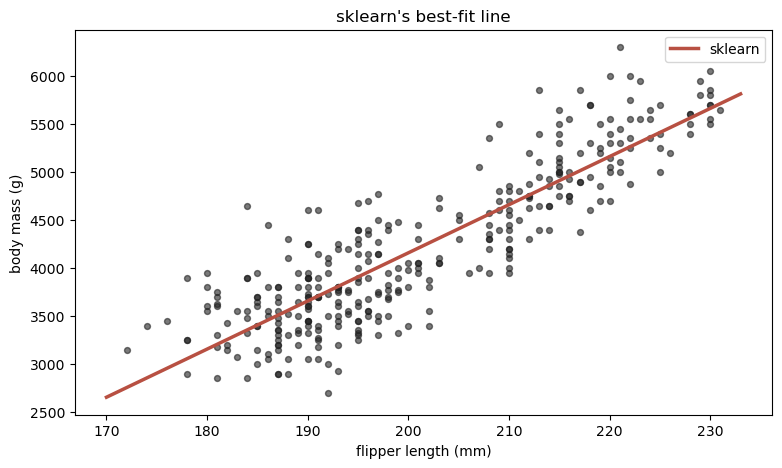

In [11]:
from sklearn.linear_model import LinearRegression

X = px_data.reshape(-1, 1)
y_sklearn = py_data

reg = LinearRegression().fit(X, y_sklearn)
sk_w = reg.coef_[0]
sk_b = reg.intercept_

sk_pred = reg.predict(X)
sk_mse = np.mean((py_data - sk_pred)**2)
sk_mae = np.mean(np.abs(py_data - sk_pred))

print(f"sklearn's best:")
print(f"  w = {sk_w:.2f}")
print(f"  b = {sk_b:.2f}")
print(f"  MSE = {sk_mse:,.0f}")
print(f"  MAE = {sk_mae:.0f}")

plt.figure(figsize=(9, 5))
plt.scatter(px_data, py_data, color=INK, s=18, alpha=0.6)
xs = np.array([px_data.min() - 2, px_data.max() + 2])
plt.plot(xs, sk_w * xs + sk_b, color=RED, lw=2.5, label='sklearn')
plt.xlabel('flipper length (mm)'); plt.ylabel('body mass (g)')
plt.title("sklearn's best-fit line")
plt.legend()
plt.show()

> **Discussion:**
> - How close did your manual guess come to sklearn's answer?
> - What we are doing here is finding optimal parameters *by eye*, in 2D, on ~300 penguins. That worked. Could you do it for 10 parameters? 100? A million (a neural network)?
> - Next session: **grid search** — let the computer try every combination on a grid. Spoiler: it works for 2 parameters and breaks for everything else. Which is why, the week after, we'll need **gradient descent**.